**part** **A**

In [ ]:
## Install Libraries
!pip install -q timm
!pip install -q albumentations
!pip install -q torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.7 MB/s eta 0:00:00


In [ ]:
## Import Libraries
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tqdm.auto import tqdm

import timm

In [ ]:
## Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
## Configuration
IMAGE_DIR="/content/drive/MyDrive/dataset/images"

IMAGE_SIZE=224

BATCH_SIZE=16

EPOCHS=30

LEARNING_RATE=1e-4

SEED=42

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :",DEVICE)

Device : cuda


In [ ]:
## Read All Images
image_files=sorted(os.listdir(IMAGE_DIR))

print("Total Images :",len(image_files))

image_files[:10]

Total Images : 2226


['High-grade IN_1.png',
 'High-grade IN_10.png',
 'High-grade IN_100.png',
 'High-grade IN_101.png',
 'High-grade IN_102.png',
 'High-grade IN_103.png',
 'High-grade IN_104.png',
 'High-grade IN_105.png',
 'High-grade IN_106.png',
 'High-grade IN_107.png']

In [ ]:
## Extract Labels Automatically
labels = []

for file in image_files:

    filename = os.path.splitext(file)[0]      # Remove .png

    label = filename.rsplit("_", 1)[0]        # Remove only the last "_number"

    label = label.strip().lower()             # Convert to lowercase

    labels.append(label)

print("Classes Found:")

print(sorted(set(labels)))

Classes Found:
['adenocarcinoma', 'high-grade in', 'low-grade in', 'normal', 'polyp', 'serrated adenoma']


In [ ]:
## Encode Labels
encoder = LabelEncoder()

encoded_labels = encoder.fit_transform(labels)

class_names = encoder.classes_

print("Classes:")

for i, cls in enumerate(class_names):

    print(i, "->", cls)

Classes:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma


In [ ]:
## Stratified Train/Validation/Test Split
train_images,temp_images,train_labels,temp_labels=train_test_split(

    image_files,

    encoded_labels,

    test_size=0.30,

    random_state=SEED,

    stratify=encoded_labels

)

val_images,test_images,val_labels,test_labels=train_test_split(

    temp_images,

    temp_labels,

    test_size=0.50,

    random_state=SEED,

    stratify=temp_labels

)

print("Train :",len(train_images))

print("Validation :",len(val_images))

print("Test :",len(test_images))

Train : 1558
Validation : 334
Test : 334


In [54]:
# ============================================================
# CREATE CLASS-WISE TEST DATASET
# ============================================================

import os
import shutil

TEST_DATASET_DIR = "/content/drive/MyDrive/Test_Dataset"

os.makedirs(
    TEST_DATASET_DIR,
    exist_ok=True
)


# ============================================================
# CREATE CLASS FOLDERS
# ============================================================

for class_name in class_names:

    class_folder = os.path.join(
        TEST_DATASET_DIR,
        class_name
    )

    os.makedirs(
        class_folder,
        exist_ok=True
    )


# ============================================================
# COPY TEST IMAGES
# ============================================================

for filename, label in zip(
    test_images,
    test_labels
):

    # Original image
    source_path = os.path.join(
        IMAGE_DIR,
        filename
    )

    # Actual class
    class_name = class_names[
        int(label)
    ]

    # Class folder
    class_folder = os.path.join(
        TEST_DATASET_DIR,
        class_name
    )

    # Destination
    destination_path = os.path.join(
        class_folder,
        filename
    )

    # Copy without changing filename
    shutil.copy2(
        source_path,
        destination_path
    )


# ============================================================
# PRINT SUMMARY
# ============================================================

print("=" * 60)
print("TEST DATASET CREATED")
print("=" * 60)

total = 0

for class_name in class_names:

    class_folder = os.path.join(
        TEST_DATASET_DIR,
        class_name
    )

    count = len(
        os.listdir(class_folder)
    )

    total += count

    print(
        f"{class_name:20s}: {count}"
    )

print("-" * 60)

print(
    f"Total test images: {total}"
)

print(
    "\nSaved at:"
)

print(
    TEST_DATASET_DIR
)

TEST DATASET CREATED
adenocarcinoma      : 120
high-grade in       : 28
low-grade in        : 95
normal              : 12
polyp               : 71
serrated adenoma    : 8
------------------------------------------------------------
Total test images: 334

Saved at:
/content/drive/MyDrive/Test_Dataset


In [ ]:
## Albumentations
train_transform=A.Compose([

    A.Resize(224,224),

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.ShiftScaleRotate(

        shift_limit=0.05,

        scale_limit=0.1,

        rotate_limit=30,

        p=0.5

    ),

    A.ColorJitter(p=0.3),

    A.RandomBrightnessContrast(p=0.3),

    A.Normalize(

        mean=(0.485,0.456,0.406),

        std=(0.229,0.224,0.225)

    ),

    ToTensorV2()

])



val_transform=A.Compose([

    A.Resize(224,224),

    A.Normalize(

        mean=(0.485,0.456,0.406),

        std=(0.229,0.224,0.225)

    ),

    ToTensorV2()

])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [ ]:
## Dataset Class + DataLoader
class TissueDataset(Dataset):

    def __init__(self,images,labels,transform=None):

        self.images=images
        self.labels=labels
        self.transform=transform

    def __len__(self):

        return len(self.images)

    def __getitem__(self,index):

        image_name=self.images[index]

        image_path=os.path.join(IMAGE_DIR,image_name)

        image=cv2.imread(image_path)

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        if self.transform:

            image=self.transform(image=image)["image"]

        label=torch.tensor(self.labels[index],dtype=torch.long)

        return image,label


train_dataset=TissueDataset(

    train_images,

    train_labels,

    train_transform

)

val_dataset=TissueDataset(

    val_images,

    val_labels,

    val_transform

)

test_dataset=TissueDataset(

    test_images,

    test_labels,

    val_transform

)

train_loader=DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=2,

    pin_memory=True

)

val_loader=DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

test_loader=DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=2,

    pin_memory=True

)

images,labels=next(iter(train_loader))

print(images.shape)

print(labels.shape)

print(class_names)

torch.Size([16, 3, 224, 224])
torch.Size([16])
['adenocarcinoma' 'high-grade in' 'low-grade in' 'normal' 'polyp'
 'serrated adenoma']


In [ ]:
print(image_files[:20])

['High-grade IN_1.png', 'High-grade IN_10.png', 'High-grade IN_100.png', 'High-grade IN_101.png', 'High-grade IN_102.png', 'High-grade IN_103.png', 'High-grade IN_104.png', 'High-grade IN_105.png', 'High-grade IN_106.png', 'High-grade IN_107.png', 'High-grade IN_108.png', 'High-grade IN_109.png', 'High-grade IN_11.png', 'High-grade IN_110.png', 'High-grade IN_111.png', 'High-grade IN_112.png', 'High-grade IN_113.png', 'High-grade IN_114.png', 'High-grade IN_115.png', 'High-grade IN_116.png']


**part B**

In [ ]:
!pip install -q torchinfo

In [ ]:
## Import Required Libraries
import timm
from torchinfo import summary

In [ ]:
## Create EfficientNet-B0 Model
model = timm.create_model(
    "efficientnet_b0",
    pretrained=True,
    num_classes=6
)

model = model.to(DEVICE)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
## View Model Architecture
print(model)

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [ ]:
## Freeze Feature Extractor
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

print("Feature Extractor Frozen")
print("Classifier Trainable")

Feature Extractor Frozen
Classifier Trainable


In [ ]:
## Count Parameters
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters      : {total_params:,}")
print(f"Trainable Parameters  : {trainable_params:,}")

Total Parameters      : 4,015,234
Trainable Parameters  : 7,686


In [ ]:
## Model Summary
summary(
    model,
    input_size=(BATCH_SIZE, 3, IMAGE_SIZE, IMAGE_SIZE)
)

Layer (type:depth-idx)                        Output Shape              Param #
EfficientNet                                  [16, 6]                   --
├─Conv2d: 1-1                                 [16, 32, 112, 112]        (864)
├─BatchNormAct2d: 1-2                         [16, 32, 112, 112]        64
│    └─Identity: 2-1                          [16, 32, 112, 112]        --
│    └─SiLU: 2-2                              [16, 32, 112, 112]        --
├─Sequential: 1-3                             [16, 320, 7, 7]           --
│    └─Sequential: 2-3                        [16, 16, 112, 112]        --
│    │    └─DepthwiseSeparableConv: 3-1       [16, 16, 112, 112]        (1,448)
│    └─Sequential: 2-4                        [16, 24, 56, 56]          --
│    │    └─InvertedResidual: 3-2             [16, 24, 56, 56]          (6,004)
│    │    └─InvertedResidual: 3-3             [16, 24, 56, 56]          (10,710)
│    └─Sequential: 2-5                        [16, 40, 28, 28]          --
│

In [ ]:
## Test Forward Pass
images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print("Input Shape :", images.shape)
print("Output Shape:", outputs.shape)

Input Shape : torch.Size([16, 3, 224, 224])
Output Shape: torch.Size([16, 6])


In [ ]:
## Check Classifier Layer
print("Final Classification Layer:\n")

print(model.classifier)

Final Classification Layer:

Linear(in_features=1280, out_features=6, bias=True)


**part** **c**

In [ ]:
## Import Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
## Loss Function
criterion = nn.CrossEntropyLoss()

print("Loss Function :", criterion)

Loss Function : CrossEntropyLoss()


In [ ]:
## Accuracy Function
def calculate_accuracy(outputs, labels):

    preds = torch.argmax(outputs, dim=1)

    acc = (preds == labels).float().mean()

    return acc.item()

In [ ]:
## Precision, Recall & F1
def calculate_metrics(outputs, labels):

    preds = torch.argmax(outputs, dim=1)

    preds = preds.cpu().numpy()

    labels = labels.cpu().numpy()

    precision = precision_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        labels,
        preds,
        average="weighted",
        zero_division=0
    )

    return precision, recall, f1

In [ ]:
# ============================================================
# STABLE LOSS + OPTIMIZER
# ============================================================

import torch
import torch.nn as nn

# ------------------------------------------------------------
# Use moderate class weighting
# ------------------------------------------------------------

class_counts = torch.tensor(
    [556, 130, 446, 53, 332, 41],
    dtype=torch.float32
)

# Square-root inverse frequency
# Less aggressive than normal inverse-frequency weighting

class_weights = 1.0 / torch.sqrt(class_counts)

# Normalize weights so average weight = 1

class_weights = (
    class_weights /
    class_weights.mean()
)

class_weights = class_weights.to(DEVICE)

print("Moderate class weights:")

for i, name in enumerate(class_names):

    print(
        f"{i} -> {name}: "
        f"{class_weights[i].item():.4f}"
    )


# ------------------------------------------------------------
# Cross Entropy
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# AdamW
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=3e-5,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# Scheduler
# ------------------------------------------------------------

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("\nStable loss and optimizer ready.")

Moderate class weights:
0 -> adenocarcinoma: 0.4839
1 -> high-grade in: 1.0007
2 -> low-grade in: 0.5402
3 -> normal: 1.5672
4 -> polyp: 0.6262
5 -> serrated adenoma: 1.7818

Stable loss and optimizer ready.


In [ ]:
# ============================================================
# SANITY CHECK
# CAN THE MODEL MEMORIZE ONE SMALL BATCH?
# ============================================================

model.train()

# Get one batch
images, labels = next(iter(train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Use a fresh optimizer
test_optimizer = torch.optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-3
)

test_criterion = nn.CrossEntropyLoss()

print("Starting sanity check...")

for step in range(100):

    test_optimizer.zero_grad()

    outputs = model(images)

    loss = test_criterion(
        outputs,
        labels
    )

    loss.backward()

    test_optimizer.step()

    if step % 10 == 0:

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        accuracy = (
            (predictions == labels)
            .float()
            .mean()
            .item()
        )

        print(
            f"Step {step:03d} | "
            f"Loss: {loss.item():.4f} | "
            f"Accuracy: {accuracy*100:.2f}%"
        )

Starting sanity check...
Step 000 | Loss: 3.4096 | Accuracy: 31.25%
Step 010 | Loss: 1.5703 | Accuracy: 56.25%
Step 020 | Loss: 0.5838 | Accuracy: 87.50%
Step 030 | Loss: 0.1833 | Accuracy: 93.75%
Step 040 | Loss: 0.0571 | Accuracy: 100.00%
Step 050 | Loss: 0.0305 | Accuracy: 100.00%
Step 060 | Loss: 0.0211 | Accuracy: 100.00%
Step 070 | Loss: 0.0165 | Accuracy: 100.00%
Step 080 | Loss: 0.0138 | Accuracy: 100.00%
Step 090 | Loss: 0.0120 | Accuracy: 100.00%


In [ ]:
"""## Learning Rate Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
    eta_min=1e-6
)

print("CosineAnnealingLR Initialized")"""

'## Learning Rate Scheduler\nscheduler = torch.optim.lr_scheduler.CosineAnnealingLR(\n    optimizer,\n    T_max=EPOCHS,\n    eta_min=1e-6\n)\n\nprint("CosineAnnealingLR Initialized")'

In [ ]:
## Training History
train_losses = []

val_losses = []

train_accuracies = []

val_accuracies = []

train_precisions = []

val_precisions = []

train_recalls = []

val_recalls = []

train_f1_scores = []

val_f1_scores = []

In [ ]:
## Best Model Variables
best_accuracy = 0.0

best_f1 = 0.0

patience = 7

counter = 0

print("Training Variables Initialized")

Training Variables Initialized


In [ ]:
## Check Trainable Layers
print("Trainable Layers:\n")

for name, param in model.named_parameters():

    if param.requires_grad:

        print(name)

Trainable Layers:

classifier.weight
classifier.bias


In [ ]:
## Forward Pass Test
images, labels = next(iter(train_loader))

images = images.to(DEVICE)

labels = labels.to(DEVICE)

outputs = model(images)

loss = criterion(outputs, labels)

accuracy = calculate_accuracy(outputs, labels)

precision, recall, f1 = calculate_metrics(outputs, labels)

print("Loss      :", loss.item())

print("Accuracy  :", accuracy)

print("Precision :", precision)

print("Recall    :", recall)

print("F1 Score  :", f1)

Loss      : 5.3321332931518555
Accuracy  : 0.0625
Precision : 0.4375
Recall    : 0.0625
F1 Score  : 0.109375


**part D**

In [ ]:
## Initialize Training Variables
best_val_loss = float("inf")

patience = 7
counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

train_precisions = []
val_precisions = []

train_recalls = []
val_recalls = []

train_f1_scores = []
val_f1_scores = []

In [ ]:
## Training Function
def train_one_epoch(model, loader, optimizer):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(),1.0)

        optimizer.step()

        running_loss += loss.item()

        preds = torch.argmax(outputs,1)

        correct += (preds==labels).sum().item()

        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss/len(loader)

    epoch_acc = accuracy_score(all_labels,all_preds)

    epoch_precision = precision_score(all_labels,all_preds,average="weighted",zero_division=0)

    epoch_recall = recall_score(all_labels,all_preds,average="weighted",zero_division=0)

    epoch_f1 = f1_score(all_labels,all_preds,average="weighted",zero_division=0)

    return epoch_loss,epoch_acc,epoch_precision,epoch_recall,epoch_f1

In [ ]:
## Validation Function
def validate(model,loader):

    model.eval()

    running_loss=0

    all_preds=[]

    all_labels=[]

    with torch.no_grad():

        for images,labels in loader:

            images=images.to(DEVICE)

            labels=labels.to(DEVICE)

            outputs=model(images)

            loss=criterion(outputs,labels)

            running_loss+=loss.item()

            preds=torch.argmax(outputs,1)

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels.cpu().numpy())

    epoch_loss=running_loss/len(loader)

    epoch_acc=accuracy_score(all_labels,all_preds)

    epoch_precision=precision_score(all_labels,all_preds,average="weighted",zero_division=0)

    epoch_recall=recall_score(all_labels,all_preds,average="weighted",zero_division=0)

    epoch_f1=f1_score(all_labels,all_preds,average="weighted",zero_division=0)

    return epoch_loss,epoch_acc,epoch_precision,epoch_recall,epoch_f1

In [49]:
# ============================================================
# FINAL IMPROVED CLASSIFICATION TRAINING
# BEST MODEL = HIGHEST VALIDATION F1
# ============================================================

import copy
import torch
from sklearn.metrics import f1_score

NUM_EPOCHS = 20

# ============================================================
# BEST MODEL TRACKING
# ============================================================

best_val_f1 = -1.0
best_val_accuracy = 0.0
best_val_loss = float("inf")
best_epoch = 0

best_model_state = None

# ============================================================
# CHECKPOINT PATH
# ============================================================

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/"
    "best_classifier_model_v3.pth"
)

# ============================================================
# TRAINING HISTORY
# ============================================================

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": []
}


# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(NUM_EPOCHS):

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        labels = labels.to(
            DEVICE,
            non_blocking=True
        )

        # Clear gradients
        optimizer.zero_grad(
            set_to_none=True
        )

        # Forward pass
        outputs = model(images)

        # Loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # ----------------------------------------------------
        # Statistics
        # ----------------------------------------------------

        running_loss += (
            loss.item() *
            images.size(0)
        )

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    train_loss = (
        running_loss / total
    )

    train_accuracy = (
        correct / total
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                DEVICE,
                non_blocking=True
            )

            labels = labels.to(
                DEVICE,
                non_blocking=True
            )

            # Forward pass
            outputs = model(images)

            # Validation loss
            loss = criterion(
                outputs,
                labels
            )

            val_running_loss += (
                loss.item() *
                images.size(0)
            )

            # Predictions
            predictions = torch.argmax(
                outputs,
                dim=1
            )

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

            all_val_preds.extend(
                predictions.cpu().numpy()
            )

            all_val_labels.extend(
                labels.cpu().numpy()
            )


    val_loss = (
        val_running_loss / val_total
    )

    val_accuracy = (
        val_correct / val_total
    )


    # ========================================================
    # VALIDATION F1
    # ========================================================

    val_f1 = f1_score(
        all_val_labels,
        all_val_preds,
        average="weighted",
        zero_division=0
    )


    # ========================================================
    # LEARNING RATE SCHEDULER
    # ========================================================

    scheduler.step(
        val_loss
    )


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_accuracy
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_accuracy
    )

    history["val_f1"].append(
        val_f1
    )


    # ========================================================
    # CURRENT LEARNING RATE
    # ========================================================

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # PRINT RESULTS
    # ========================================================

    print(
        f"\nEpoch [{epoch + 1}/{NUM_EPOCHS}]"
    )

    print(
        f"Train Loss      : "
        f"{train_loss:.4f}"
    )

    print(
        f"Train Accuracy  : "
        f"{train_accuracy:.4f}"
    )

    print(
        f"Val Loss        : "
        f"{val_loss:.4f}"
    )

    print(
        f"Val Accuracy    : "
        f"{val_accuracy:.4f}"
    )

    print(
        f"Val F1          : "
        f"{val_f1:.4f}"
    )

    print(
        f"Learning Rate   : "
        f"{current_lr:.7f}"
    )


    # ========================================================
    # SAVE BEST MODEL
    #
    # IMPORTANT:
    # We use VAL F1 as the main criterion.
    # ========================================================

    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        best_val_accuracy = val_accuracy
        best_val_loss = val_loss
        best_epoch = epoch + 1

        # Copy model weights into memory
        best_model_state = copy.deepcopy(
            model.state_dict()
        )

        # ----------------------------------------------------
        # Save complete checkpoint
        # ----------------------------------------------------

        checkpoint = {

            "epoch": best_epoch,

            "model_state_dict":
                best_model_state,

            "optimizer_state_dict":
                optimizer.state_dict(),

            "scheduler_state_dict":
                scheduler.state_dict(),

            "best_val_loss":
                best_val_loss,

            "best_val_accuracy":
                best_val_accuracy,

            "best_val_f1":
                best_val_f1,

            "class_names":
                class_names
        }


        torch.save(
            checkpoint,
            BEST_MODEL_PATH
        )


        print(
            "\n✓ BEST MODEL UPDATED"
        )

        print(
            f"  Epoch       : {best_epoch}"
        )

        print(
            f"  Val Loss    : "
            f"{best_val_loss:.4f}"
        )

        print(
            f"  Val Accuracy: "
            f"{best_val_accuracy:.4f}"
        )

        print(
            f"  Val F1      : "
            f"{best_val_f1:.4f}"
        )

        print(
            f"  Saved to    : "
            f"{BEST_MODEL_PATH}"
        )


# ============================================================
# TRAINING COMPLETED
# ============================================================

print("\n========================================")
print("TRAINING COMPLETED")
print("========================================")

print(
    f"Best Epoch       : {best_epoch}"
)

print(
    f"Best Val Loss    : "
    f"{best_val_loss:.4f}"
)

print(
    f"Best Val Accuracy: "
    f"{best_val_accuracy:.4f}"
)

print(
    f"Best Val F1      : "
    f"{best_val_f1:.4f}"
)

print(
    f"Best Model Path  : "
    f"{BEST_MODEL_PATH}"
)


# ============================================================
# LOAD BEST MODEL BACK INTO MODEL
# ============================================================

if best_model_state is not None:

    model.load_state_dict(
        best_model_state
    )

    model = model.to(
        DEVICE
    )

    model.eval()

    print(
        "\n✓ Best model loaded back into memory."
    )

else:

    print(
        "\nWARNING: No best model was saved."
    )


Epoch [1/20]
Train Loss      : 2.4726
Train Accuracy  : 0.3793
Val Loss        : 1.4413
Val Accuracy    : 0.6018
Val F1          : 0.6430
Learning Rate   : 0.0000300

✓ BEST MODEL UPDATED
  Epoch       : 1
  Val Loss    : 1.4413
  Val Accuracy: 0.6018
  Val F1      : 0.6430
  Saved to    : /content/drive/MyDrive/best_classifier_model_v3.pth

Epoch [2/20]
Train Loss      : 1.2844
Train Accuracy  : 0.6226
Val Loss        : 1.1616
Val Accuracy    : 0.6946
Val F1          : 0.7173
Learning Rate   : 0.0000300

✓ BEST MODEL UPDATED
  Epoch       : 2
  Val Loss    : 1.1616
  Val Accuracy: 0.6946
  Val F1      : 0.7173
  Saved to    : /content/drive/MyDrive/best_classifier_model_v3.pth

Epoch [3/20]
Train Loss      : 1.0902
Train Accuracy  : 0.6958
Val Loss        : 1.0247
Val Accuracy    : 0.7246
Val F1          : 0.7460
Learning Rate   : 0.0000300

✓ BEST MODEL UPDATED
  Epoch       : 3
  Val Loss    : 1.0247
  Val Accuracy: 0.7246
  Val F1      : 0.7460
  Saved to    : /content/drive/MyDri

In [50]:
# ============================================================
# LOAD BEST MODEL
# ============================================================

CHECKPOINT_PATH = "/content/drive/MyDrive/best_classifier_model_v3.pth"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("========================================")
print("BEST MODEL LOADED")
print("========================================")

print("Epoch:", checkpoint.get("epoch"))
print("Best Val Loss:", checkpoint.get("best_val_loss"))
print("Best Val F1:", checkpoint.get("best_val_f1"))

print("Class names:")
for i, name in enumerate(checkpoint["class_names"]):
    print(i, "->", name)

BEST MODEL LOADED
Epoch: 11
Best Val Loss: 0.6482385925190177
Best Val F1: 0.8062891888748814
Class names:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma


In [51]:
# ============================================================
# FINAL TEST EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        predictions = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )


# ============================================================
# METRICS
# ============================================================

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)


print("\n========================================")
print("FINAL TEST RESULTS")
print("========================================")

print(
    f"Accuracy  : {accuracy:.4f}"
)

print(
    f"Precision : {precision:.4f}"
)

print(
    f"Recall    : {recall:.4f}"
)

print(
    f"F1 Score  : {f1:.4f}"
)


print("\nClassification Report:")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    )
)


FINAL TEST RESULTS
Accuracy  : 0.8204
Precision : 0.8440
Recall    : 0.8204
F1 Score  : 0.8276

Classification Report:
                  precision    recall  f1-score   support

  adenocarcinoma       0.94      0.93      0.94       120
   high-grade in       0.55      0.57      0.56        28
    low-grade in       0.88      0.78      0.83        95
          normal       0.43      0.83      0.57        12
           polyp       0.86      0.79      0.82        71
serrated adenoma       0.43      0.75      0.55         8

        accuracy                           0.82       334
       macro avg       0.68      0.78      0.71       334
    weighted avg       0.84      0.82      0.83       334



Best model loaded successfully.
Best epoch: 11



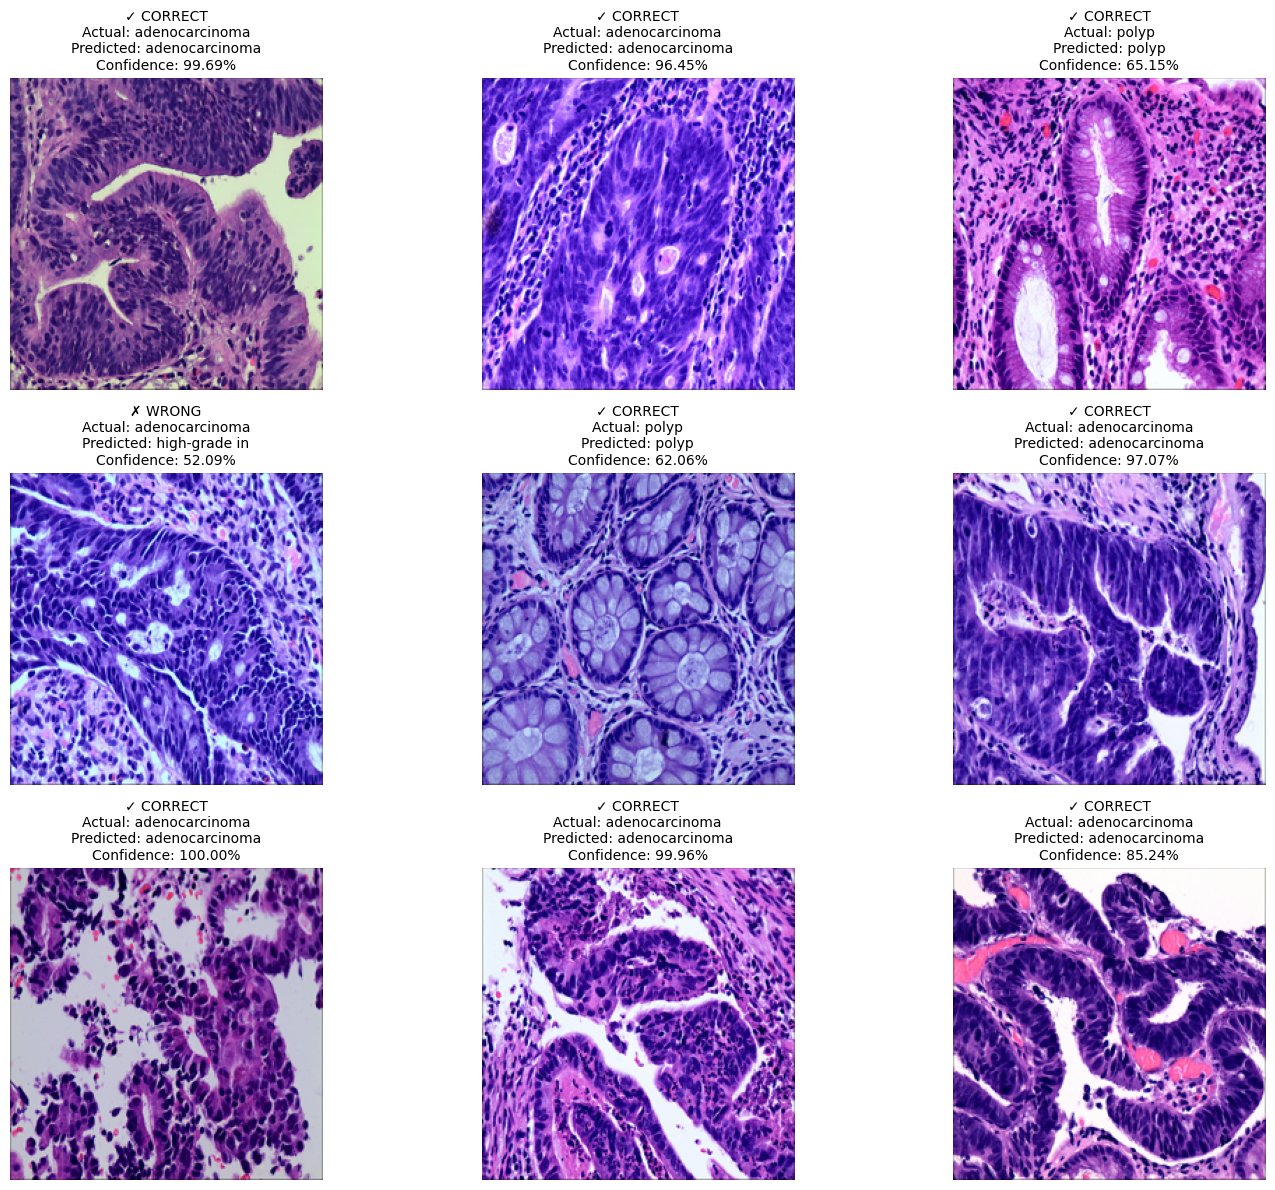

In [52]:
# ============================================================
# SHOW TEST DATA PREDICTIONS
# Using best_classifier_model_v3.pth
# ============================================================

import torch
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Make sure best model is loaded
# ------------------------------------------------------------

CHECKPOINT_PATH = "/content/drive/MyDrive/best_classifier_model_v3.pth"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

# Use class names saved with the checkpoint
class_names = checkpoint["class_names"]

print("Best model loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print()


# ============================================================
# GET ONE BATCH FROM TEST DATA
# ============================================================

images, labels = next(iter(test_loader))

images_gpu = images.to(DEVICE)

with torch.inference_mode():

    outputs = model(images_gpu)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predictions = torch.argmax(
        probabilities,
        dim=1
    )

    confidences = torch.max(
        probabilities,
        dim=1
    ).values


# Move to CPU
images = images.cpu()
labels = labels.cpu()
predictions = predictions.cpu()
confidences = confidences.cpu()


# ============================================================
# DISPLAY 9 TEST IMAGES
# ============================================================

plt.figure(figsize=(15, 12))

for i in range(min(9, len(images))):

    # --------------------------------------------------------
    # Get image
    # --------------------------------------------------------

    img = images[i].permute(
        1, 2, 0
    ).numpy()

    # --------------------------------------------------------
    # Undo ImageNet normalization
    # --------------------------------------------------------

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    img = (
        img * std
    ) + mean

    img = np.clip(
        img,
        0,
        1
    )


    # --------------------------------------------------------
    # Actual / predicted
    # --------------------------------------------------------

    actual_index = labels[i].item()

    predicted_index = predictions[i].item()

    actual_class = class_names[
        actual_index
    ]

    predicted_class = class_names[
        predicted_index
    ]

    confidence = (
        confidences[i].item() * 100
    )


    # --------------------------------------------------------
    # Plot
    # --------------------------------------------------------

    plt.subplot(3, 3, i + 1)

    plt.imshow(img)

    plt.axis("off")

    if actual_index == predicted_index:

        result = "✓ CORRECT"

    else:

        result = "✗ WRONG"


    plt.title(
        f"{result}\n"
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%",
        fontsize=10
    )


plt.tight_layout()

plt.show()

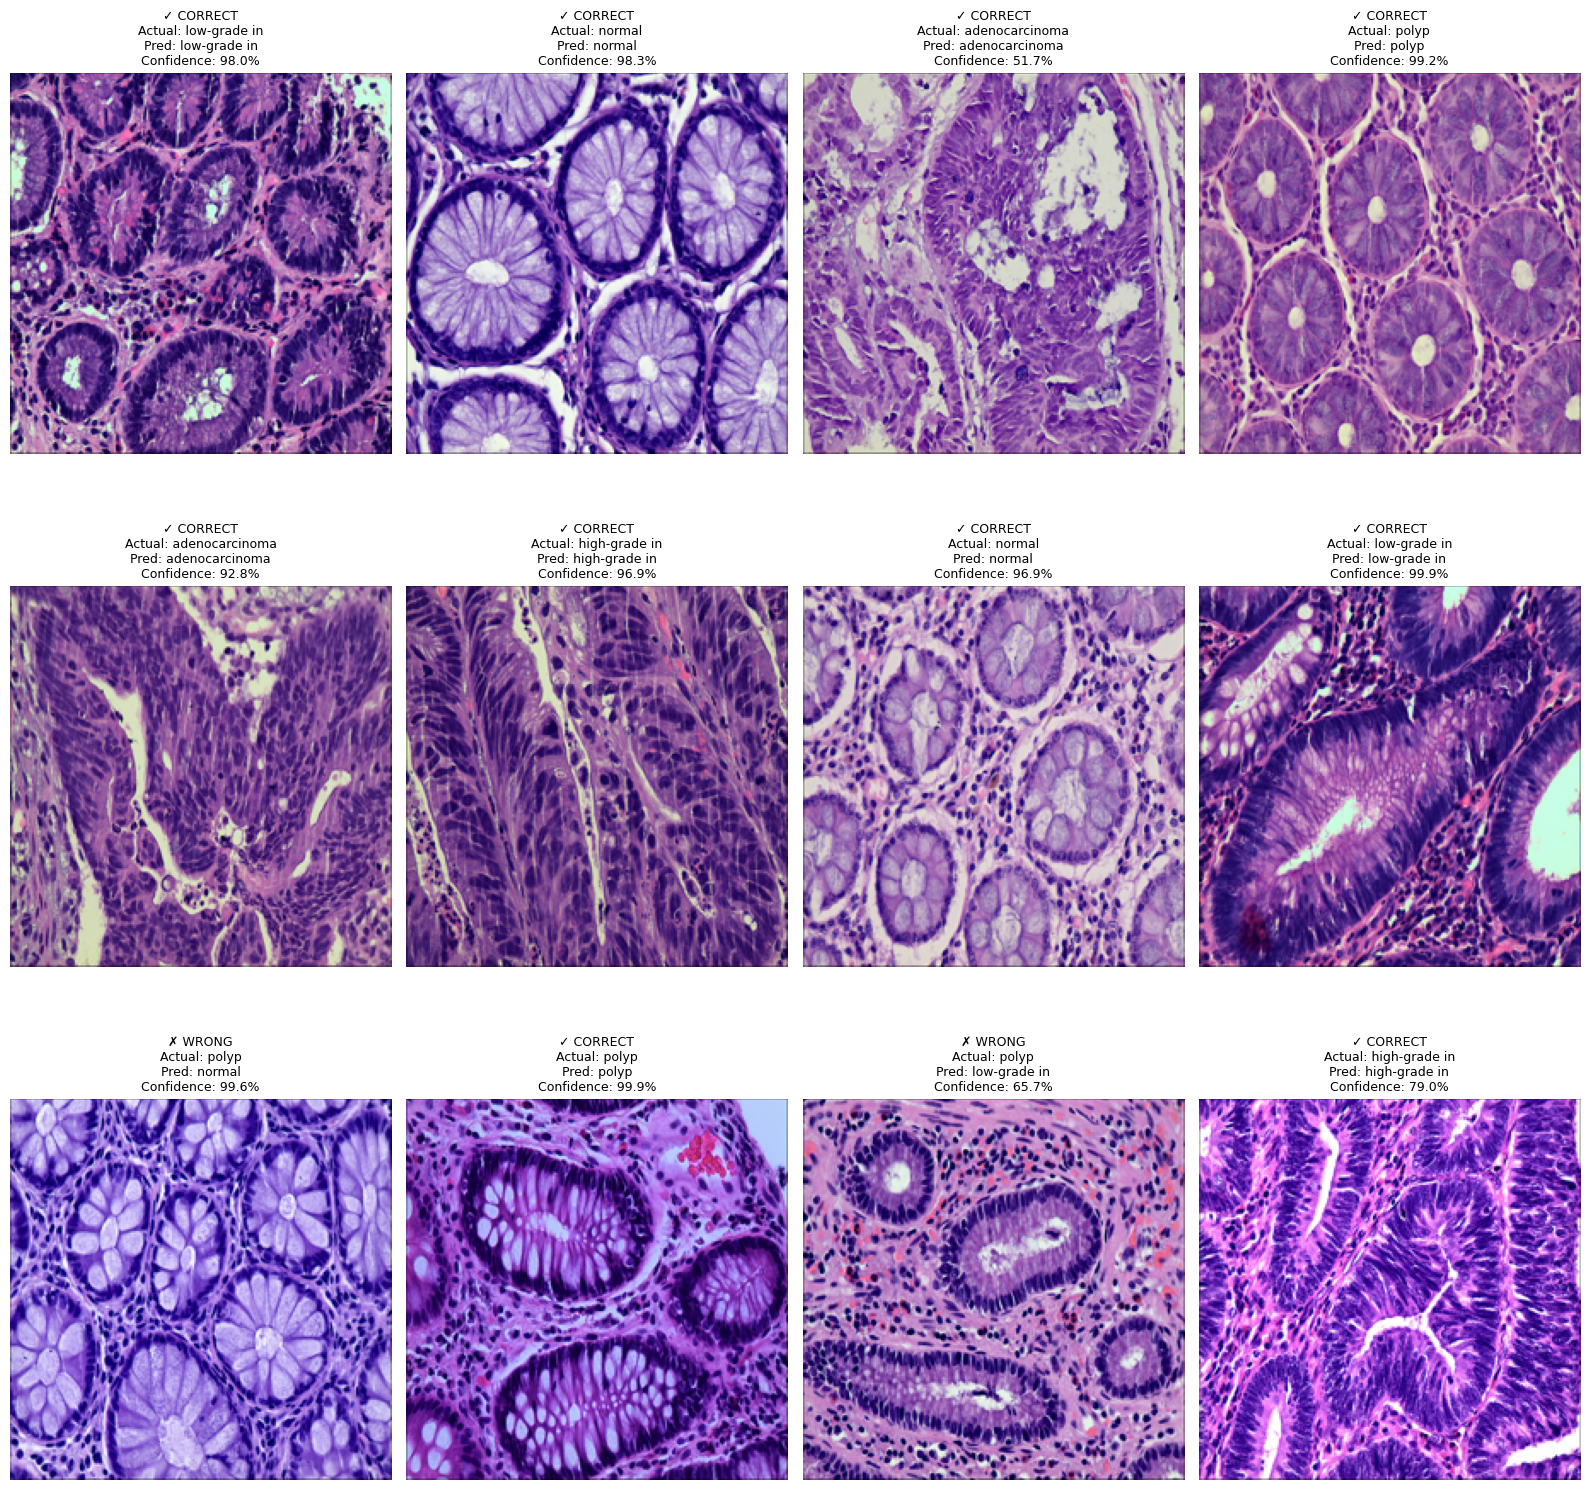

In [53]:
# ============================================================
# RANDOM TEST IMAGES FROM ENTIRE TEST DATASET
# ============================================================

import random
import matplotlib.pyplot as plt
import numpy as np
import torch

model.eval()

# Select 12 random test samples
indices = random.sample(
    range(len(test_dataset)),
    min(12, len(test_dataset))
)

plt.figure(figsize=(16, 16))

for plot_number, dataset_index in enumerate(indices):

    # Get image and label
    image, label = test_dataset[dataset_index]

    # Add batch dimension
    image_input = image.unsqueeze(0).to(DEVICE)

    # Prediction
    with torch.inference_mode():

        output = model(
            image_input
        )

        probability = torch.softmax(
            output,
            dim=1
        )

        predicted_index = torch.argmax(
            probability,
            dim=1
        ).item()

        confidence = probability[
            0,
            predicted_index
        ].item() * 100


    # --------------------------------------------------------
    # Convert image back for display
    # --------------------------------------------------------

    img = image.permute(
        1, 2, 0
    ).numpy()

    mean = np.array(
        [0.485, 0.456, 0.406]
    )

    std = np.array(
        [0.229, 0.224, 0.225]
    )

    img = (
        img * std
    ) + mean

    img = np.clip(
        img,
        0,
        1
    )


    actual_class = class_names[
        label.item()
    ]

    predicted_class = class_names[
        predicted_index
    ]


    if label.item() == predicted_index:

        result = "✓ CORRECT"

    else:

        result = "✗ WRONG"


    # --------------------------------------------------------
    # Display
    # --------------------------------------------------------

    plt.subplot(3, 4, plot_number + 1)

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"{result}\n"
        f"Actual: {actual_class}\n"
        f"Pred: {predicted_class}\n"
        f"Confidence: {confidence:.1f}%",
        fontsize=9
    )


plt.tight_layout()

plt.show()

In [42]:
# ============================================================
# LOAD BEST SAVED MODEL
# ============================================================

BEST_MODEL_PATH = "/content/drive/MyDrive/best_classifier_model_v2.pth"

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("Checkpoint keys:")
print(checkpoint.keys())

# Load model weights
model.load_state_dict(
    checkpoint["model_state_dict"]
)

# Load class names saved during training
if "class_names" in checkpoint:
    class_names = checkpoint["class_names"]

print("\nSaved class names:")
for i, name in enumerate(class_names):
    print(i, "->", name)

model = model.to(DEVICE)
model.eval()

print("\nBest model loaded successfully.")

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_loss', 'best_val_f1', 'class_names'])

Saved class names:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma

Best model loaded successfully.


In [43]:
# ============================================================
# TEST BEST MODEL
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

accuracy = accuracy_score(
    all_labels,
    all_preds
)

precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("\n==============================")
print("FINAL TEST RESULTS")
print("==============================")

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        zero_division=0
    )
)


FINAL TEST RESULTS
Accuracy  : 0.1317
Precision : 0.3096
Recall    : 0.1317
F1 Score  : 0.1740

Classification Report:
                  precision    recall  f1-score   support

  adenocarcinoma       0.46      0.15      0.23       120
   high-grade in       0.05      0.14      0.08        28
    low-grade in       0.36      0.14      0.20        95
          normal       0.02      0.08      0.03        12
           polyp       0.17      0.11      0.14        71
serrated adenoma       0.00      0.00      0.00         8

        accuracy                           0.13       334
       macro avg       0.18      0.10      0.11       334
    weighted avg       0.31      0.13      0.17       334



In [44]:
# ============================================================
# DIAGNOSTIC 1 - VERIFY MODEL + TEST DATA
# ============================================================

model.eval()

print("========================================")
print("MODEL / DATA DIAGNOSTIC")
print("========================================")

print("Model:", type(model).__name__)
print("Device:", DEVICE)

print("\nClass names:")
for i, name in enumerate(class_names):
    print(i, "->", name)

print("\nTest dataset size:", len(test_dataset))
print("Test loader size:", len(test_loader))

# ------------------------------------------------------------
# Check one test batch
# ------------------------------------------------------------

images, labels = next(iter(test_loader))

print("\nTest batch:")
print("Images shape :", images.shape)
print("Labels shape :", labels.shape)

print("\nLabels in first batch:")
print(labels.tolist())

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------

images_device = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images_device)

    probabilities = torch.softmax(
        outputs,
        dim=1
    )

    predictions = torch.argmax(
        probabilities,
        dim=1
    )

print("\nPredictions:")
print(predictions.cpu().tolist())

print("\nActual:")
print(labels.tolist())

# ------------------------------------------------------------
# Compare
# ------------------------------------------------------------

correct = (
    predictions.cpu() == labels
).sum().item()

total = len(labels)

print(
    f"\nFirst batch accuracy: "
    f"{correct}/{total} = "
    f"{correct/total*100:.2f}%"
)

print("\nFirst batch prediction distribution:")

for i, name in enumerate(class_names):

    count = (
        predictions.cpu() == i
    ).sum().item()

    print(
        f"{i} -> {name}: {count}"
    )

MODEL / DATA DIAGNOSTIC
Model: EfficientNet
Device: cuda

Class names:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma

Test dataset size: 334
Test loader size: 21

Test batch:
Images shape : torch.Size([16, 3, 224, 224])
Labels shape : torch.Size([16])

Labels in first batch:
[0, 0, 4, 0, 4, 0, 0, 0, 0, 4, 0, 4, 0, 2, 2, 2]

Predictions:
[4, 3, 5, 1, 1, 3, 5, 0, 5, 3, 4, 5, 1, 4, 5, 5]

Actual:
[0, 0, 4, 0, 4, 0, 0, 0, 0, 4, 0, 4, 0, 2, 2, 2]

First batch accuracy: 1/16 = 6.25%

First batch prediction distribution:
0 -> adenocarcinoma: 1
1 -> high-grade in: 3
2 -> low-grade in: 0
3 -> normal: 3
4 -> polyp: 3
5 -> serrated adenoma: 6


In [45]:
# ============================================================
# DIAGNOSTIC 2 - VALIDATION VS TEST
# ============================================================

def evaluate_loader(loader, loader_name):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(DEVICE)

            outputs = model(images)

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = (
        all_preds == all_labels
    ).mean()

    print("\n========================================")
    print(loader_name)
    print("========================================")

    print(
        "Samples:",
        len(all_labels)
    )

    print(
        f"Accuracy: {accuracy*100:.2f}%"
    )

    print("\nPrediction distribution:")

    for i, name in enumerate(class_names):

        actual_count = (
            all_labels == i
        ).sum()

        predicted_count = (
            all_preds == i
        ).sum()

        print(
            f"{i} -> {name:<20} "
            f"Actual: {actual_count:<4} "
            f"Predicted: {predicted_count:<4}"
        )


# Evaluate validation
evaluate_loader(
    val_loader,
    "VALIDATION SET"
)

# Evaluate test
evaluate_loader(
    test_loader,
    "TEST SET"
)



VALIDATION SET
Samples: 334
Accuracy: 15.27%

Prediction distribution:
0 -> adenocarcinoma       Actual: 119  Predicted: 25  
1 -> high-grade in        Actual: 28   Predicted: 78  
2 -> low-grade in         Actual: 96   Predicted: 38  
3 -> normal               Actual: 11   Predicted: 69  
4 -> polyp                Actual: 71   Predicted: 47  
5 -> serrated adenoma     Actual: 9    Predicted: 77  

TEST SET
Samples: 334
Accuracy: 13.17%

Prediction distribution:
0 -> adenocarcinoma       Actual: 120  Predicted: 39  
1 -> high-grade in        Actual: 28   Predicted: 78  
2 -> low-grade in         Actual: 95   Predicted: 36  
3 -> normal               Actual: 12   Predicted: 58  
4 -> polyp                Actual: 71   Predicted: 47  
5 -> serrated adenoma     Actual: 8    Predicted: 76  


In [46]:
# ============================================================
# CHECK EXACT CHECKPOINT
# ============================================================

CHECKPOINT_PATH = "/content/drive/MyDrive/best_classifier_model_v2.pth"

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False
)

print("========================================")
print("CHECKPOINT INFORMATION")
print("========================================")

print("Checkpoint type:")
print(type(checkpoint))

if isinstance(checkpoint, dict):

    print("\nCheckpoint keys:")
    print(checkpoint.keys())

    if "epoch" in checkpoint:
        print("\nSaved epoch:", checkpoint["epoch"])

    if "best_val_loss" in checkpoint:
        print("Best validation loss:",
              checkpoint["best_val_loss"])

    if "class_names" in checkpoint:
        print("\nSaved class names:")
        for i, name in enumerate(checkpoint["class_names"]):
            print(i, "->", name)

    if "model_state_dict" in checkpoint:
        print("\nModel state dict found: YES")

        print(
            "Number of parameters:",
            len(checkpoint["model_state_dict"])
        )

    else:
        print("\nModel state dict found: NO")

else:

    print("Checkpoint is directly a state_dict.")


CHECKPOINT INFORMATION
Checkpoint type:
<class 'dict'>

Checkpoint keys:
dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'best_val_loss', 'best_val_f1', 'class_names'])

Saved epoch: 2
Best validation loss: 4.39450610611967

Saved class names:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma

Model state dict found: YES
Number of parameters: 360


In [47]:
# ============================================================
# CHECK SAVED CHECKPOINT METRICS
# ============================================================

checkpoint = torch.load(
    "/content/drive/MyDrive/best_classifier_model_v2.pth",
    map_location=DEVICE,
    weights_only=False
)

print("========================================")
print("SAVED CHECKPOINT DETAILS")
print("========================================")

print("Saved epoch:")
print(checkpoint["epoch"])

print("\nBest validation loss:")
print(checkpoint["best_val_loss"])

print("\nBest validation F1:")
print(checkpoint["best_val_f1"])

print("\nClass names:")
for i, name in enumerate(checkpoint["class_names"]):
    print(i, "->", name)

SAVED CHECKPOINT DETAILS
Saved epoch:
2

Best validation loss:
4.39450610611967

Best validation F1:
0.14391149755174468

Class names:
0 -> adenocarcinoma
1 -> high-grade in
2 -> low-grade in
3 -> normal
4 -> polyp
5 -> serrated adenoma


In [48]:
# ============================================================
# LOAD THIS EXACT CHECKPOINT
# ============================================================

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print("Checkpoint loaded successfully.")

Checkpoint loaded successfully.


In [ ]:
  ## Load Best Model
checkpoint = torch.load(
    "/content/drive/MyDrive/best_classifier_model.pth",
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

print("✅ Best Model Loaded Successfully")
print(f"Saved Epoch       : {checkpoint['epoch'] + 1}")
print(f"Best Validation Loss : {checkpoint['best_val_loss']:.4f}")

ValueError: loaded state dict contains a parameter group that doesn't match the size of optimizer's group

In [ ]:
import os

path="/content/drive/MyDrive/best_classifier_model.pth"

print(os.path.exists(path))

True


**part E**

In [ ]:
## Test the Model
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Testing Completed")

Testing Completed


In [ ]:
## Calculate Test Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

test_accuracy = accuracy_score(all_labels, all_preds)

test_precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

print("="*50)
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Precision     : {test_precision:.4f}")
print(f"Recall        : {test_recall:.4f}")
print(f"F1 Score      : {test_f1:.4f}")
print("="*50)

Test Accuracy : 0.0210
Precision     : 0.0556
Recall        : 0.0210
F1 Score      : 0.0203


In [ ]:
## Classification Report
from sklearn.metrics import classification_report

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

  adenocarcinoma       0.08      0.02      0.03       120
   high-grade in       0.03      0.11      0.05        28
    low-grade in       0.00      0.00      0.00        95
          normal       0.01      0.08      0.02        12
           polyp       0.11      0.01      0.03        71
serrated adenoma       0.00      0.00      0.00         8

        accuracy                           0.02       334
       macro avg       0.04      0.04      0.02       334
    weighted avg       0.06      0.02      0.02       334



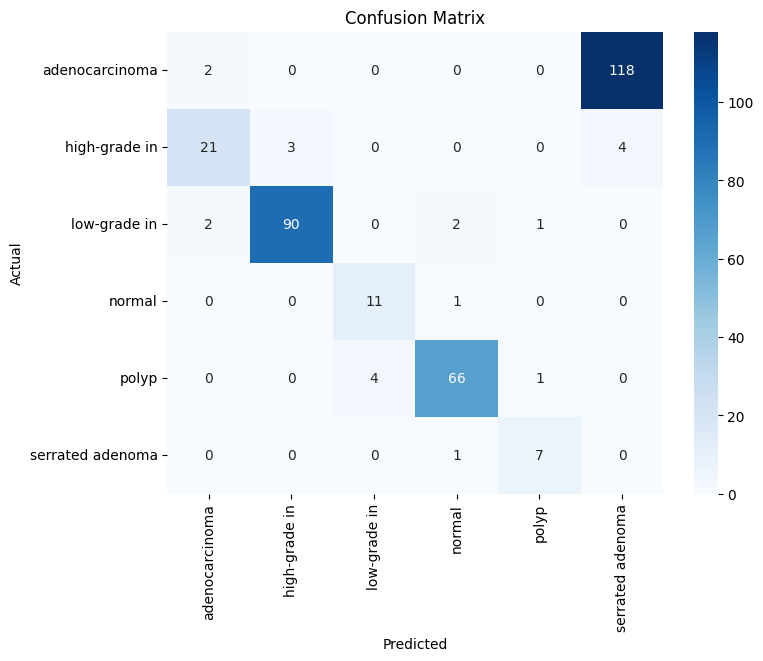

In [ ]:
## Confusion Matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

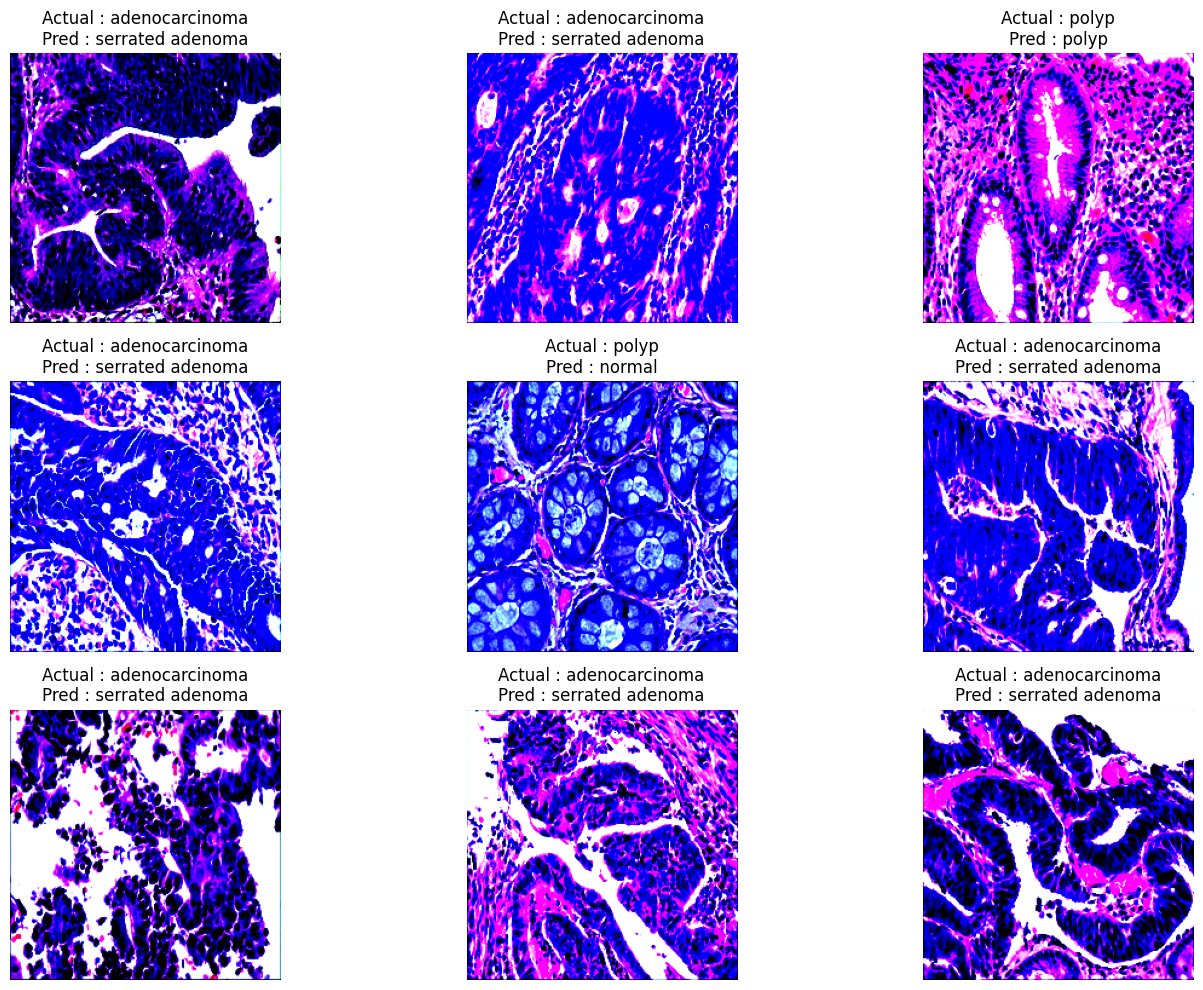

In [ ]:
## Show Sample Predictions
images, labels = next(iter(test_loader))

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

preds = torch.argmax(outputs, dim=1)

images = images.cpu()

plt.figure(figsize=(15,10))

for i in range(min(9, len(images))):

    plt.subplot(3,3,i+1)

    img = images[i].permute(1,2,0).numpy()

    plt.imshow(img)

    plt.axis("off")

    plt.title(
        f"Actual : {class_names[labels[i]]}\n"
        f"Pred : {class_names[preds[i].cpu()]}"
    )

plt.tight_layout()

plt.show()

In [ ]:
## Save Final Model
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/final_classifier_model_weights.pth"
)

print("Final Model Saved Successfully")

Final Model Saved Successfully


In [ ]:
## Verify Saved Files
import os

print("Checkpoint Exists :",
      os.path.exists("/content/drive/MyDrive/best_classifier_model.pth"))

print("Final Weights Exists :",
      os.path.exists("/content/drive/MyDrive/final_classifier_model_weights.pth"))

Checkpoint Exists : True
Final Weights Exists : True
